# Paper figures

Here we reproduce the figures in the order they appear in the paper.

In [233]:
# Import libraries

from src.spectrogram import *
from src.barycenter import *
from src.cost_matrix import *
from src.display import *
from src.spectrogram import *
from src.synthetic_signals import *
from src.utils import *

import matplotlib.pyplot as plt
import librosa
from scipy.signal.windows import hann

from time import time

## Fig. 1 - Effects of window length on the spectrogram

Computing UOT... Convergence attained after 53 iterations.


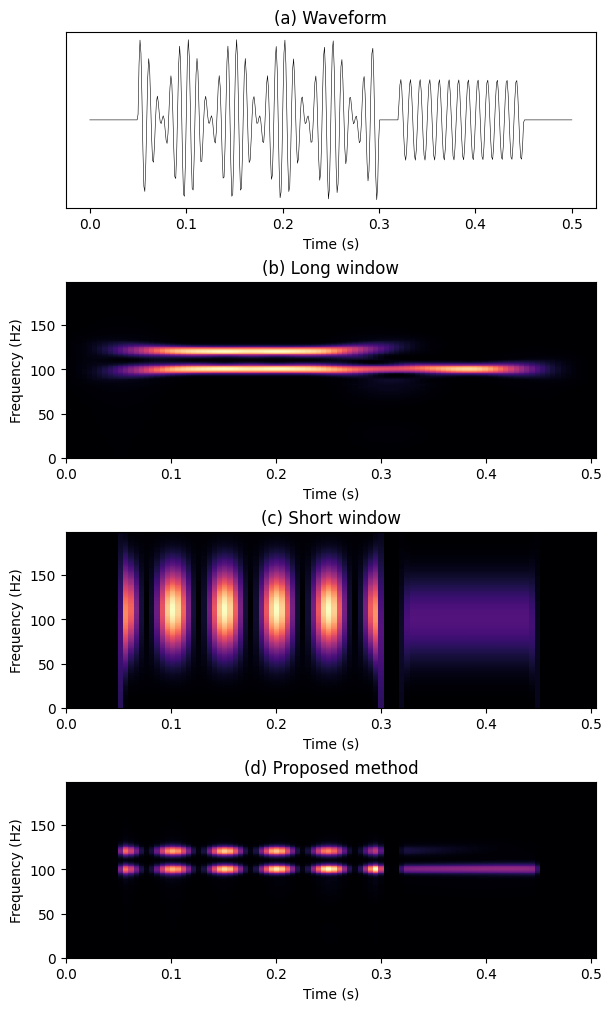

In [234]:
sr = 1000 # sample rate
t, signal = generate_toy_signal(sr)

# Ccompute input spectrograms
X1 = Spectrogram(signal, sr=sr, window_size_s=180e-3, hop_size_s=5e-3, nfft=1024)
X2 = Spectrogram(signal, sr=sr, window_size_s=20e-3, hop_size_s=5e-3, nfft=1024)

x1 = X1.spectrogram()
x2 = X2.spectrogram()

## Compute UOT over same support spectrograms
# First truncate last frames of x1 to ensure same shape
x1 = x1[:, :X2.t] # X2.t is the number of frames in x2
X1.t_frames = X1.t_frames[:X2.t]

# Define t-f supports
S1 = time_freq_support(X1.f_bins, X1.t_frames, norm=True) # High-frequency spectrogram grid
S2 = time_freq_support(X2.f_bins, X2.t_frames, norm=True) # High-temporal spectrogram grid
S  = time_freq_support(X1.f_bins, X2.t_frames, norm=True) # High-resolution spectrogram grid

c1, rows1, cols1 = cost_matrix_horizontal_overlap(S1, S, X1.window_size, X2.window_size, X1.hop_size, X2.hop_size)
c2, rows2, cols2 = cost_matrix_vertical_overlap(S2, S, X1.window_size, X2.window_size)

print("Computing UOT...", end=' ')
x_uot, loss, diff = uot_barycenter(x1.T.flatten(), 
                                   x2.T.flatten(), 
                                   c1, 
                                   c2, 
                                   rows1,
                                   cols1,
                                   rows2,
                                   cols2,
                                   eta=100,
                                   bary_size=x1.shape[0] * x2.shape[1],
                                   nItermax=500,
                                   verbose=True,
                                   return_loss=True,
                                   return_diff=True,
                                   thr=1e-5)

x_uot = x_uot.reshape(X2.t, X1.f).T

axes = new_axes(4, 1, figsize=[6, 10]) # 4 rows, 1 col
plot_signal(signal, times=t, ax=axes[0], title='(a) Waveform')
display_spectrogram(x1, ax=axes[1], f_bins=X1.f_bins, t_frames=X1.t_frames, high_f=200, title='(b) Long window') # in paper we remove last frames of x1 for readability
display_spectrogram(x2, ax=axes[2], f_bins=X2.f_bins, t_frames=X2.t_frames, high_f=200, title='(c) Short window')
display_spectrogram(x_uot, ax=axes[3], f_bins=X1.f_bins, t_frames=X2.t_frames, high_f=200, title='(d) Proposed method')

## Fig. 2 - Time-frequency grids used for OT

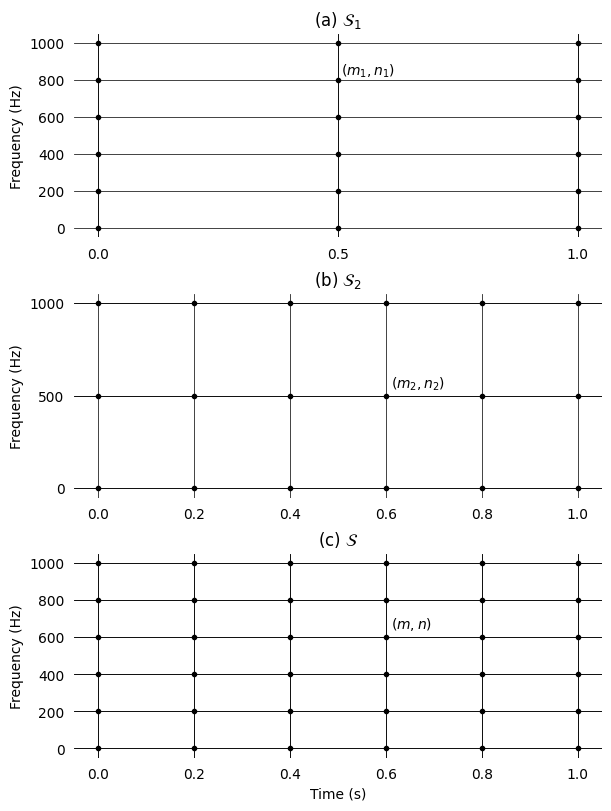

In [235]:
f_bins_1   = np.linspace(0, 1000, 6) # 6 bins from 0 to 1kHz
f_bins_2   = np.linspace(0, 1000, 3) # 3 bins from 0 to 1kHz

t_frames_1 = np.linspace(0, 1, 3) # 3 frames from 0 to 1 second
t_frames_2 = np.linspace(0, 1, 6) # 6 frames from 0 to 1 second

S1 = time_freq_support(f_bins_1, t_frames_1)
S2 = time_freq_support(f_bins_2, t_frames_2)
S  = time_freq_support(f_bins_1, t_frames_2)

axes = new_axes(3, 1, figsize=[6, 8])

display_support(S1, ax=axes[0], title=r'(a) $\mathcal{S}_1$', xlabel='', add_point=True, point_pos=(.505, .86), point_label=r'$(m_1, n_1)$')
display_support(S2, ax=axes[1], title=r'(b) $\mathcal{S}_2$', xlabel='', add_point=True, point_pos=(.6, .6), point_label=r'$(m_2, n_2)$')
display_support(S , ax=axes[2], title=r'(c) $\mathcal{S}$', add_point=True, point_pos=(.6, .7), point_label=r'$(m, n)$')

## Fig. 3 - Initial results

### Load signal and spectrograms

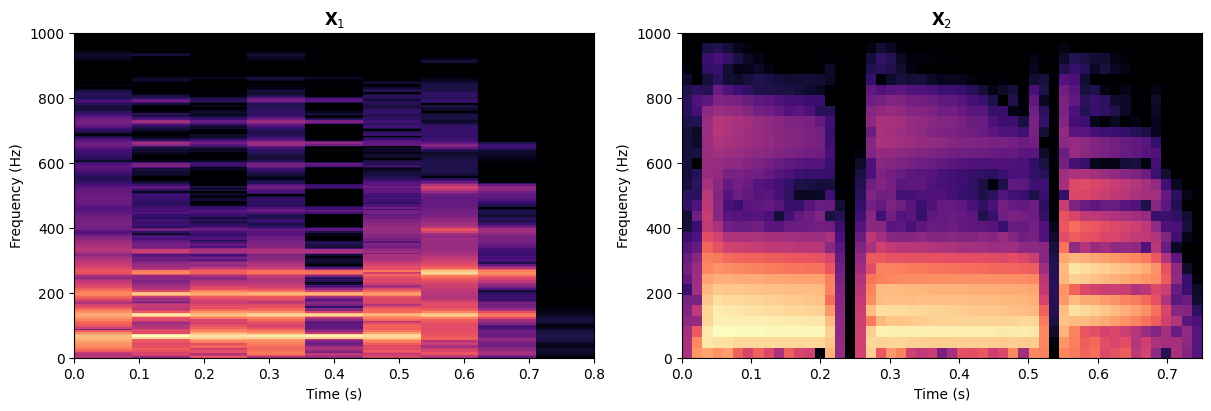

In [236]:
sr = 2000 # setting sr low to run OT (might need to reduce this further if OT doesn't work)
signal, _ = librosa.load('example_sounds/bass_notes.wav', sr=sr) 

X1 = Spectrogram(signal, sr=sr, window_size_s=200e-3)
X2 = Spectrogram(signal, sr=sr, window_size_s=30e-3)
x1 = X1.spectrogram()
x1 /= x1.sum() # normalization required for OT
x2 = X2.spectrogram()
x2 /= x2.sum() # normalization required for OT

axes = new_axes(1, 2)

display_spectrogram(x1, ax=axes[0], f_bins=X1.f_bins, t_frames=X1.t_frames, log=True, logmin=-80, title=r"$\mathbf{X}_1$")
display_spectrogram(x2, ax=axes[1], f_bins=X2.f_bins, t_frames=X2.t_frames, log=True, logmin=-80, title=r"$\mathbf{X}_2$")

### Squared Euclidean OT

Compute cost matrices for OT

In [237]:
S1 = time_freq_support(X1.f_bins, X1.t_frames, norm=True) # High-frequency spectrogram grid
S2 = time_freq_support(X2.f_bins, X2.t_frames, norm=True) # High-temporal spectrogram grid
S  = time_freq_support(X1.f_bins, X2.t_frames, norm=True) # High-resolution spectrogram grid

C1 = sq_cost_matrix(S1, S)
C2 = sq_cost_matrix(S2, S)

print(f"C1 has {C1.size} finite values.")
print(f"C2 has {C2.size} finite values.")

C1 has 18544059 finite values.
C2 has 16206831 finite values.


Compute OT barycenter

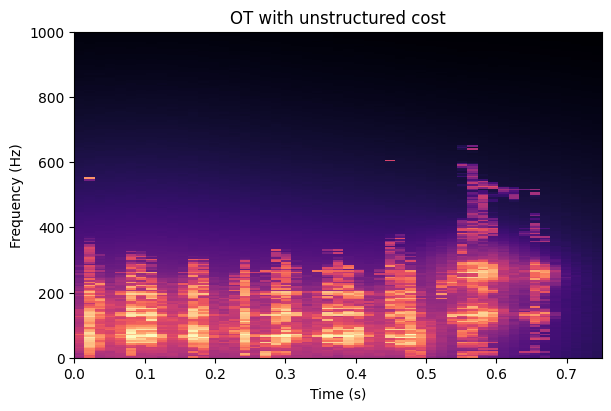

In [238]:
# take x.T.flatten() so that weights are vectorized in a column-wise fashion.

# UNCOMMENT THE FOLLOWING LINES TO COMPUTE THE OT BARYCENTER
# TAKES A LONG TIME (for 1000 iterations)
# x_OT, loss_OT, diff_OT = ot_barycenter(x1.T.flatten(), x2.T.flatten(), C1, C2, nItermax=1000, thr=0, return_diff=True, return_loss=True, verbose=True)
# x_OT = x_OT.reshape(X2.t, X1.f).T
# np.save('data/ot_barycenter.npy', x_OT)
# np.save('data/ot_loss.npy', loss_OT)
# np.save('data/ot_diff.npy', diff_OT)

# LOAD THE OT BARYCENTER DIRECTLY
x_OT = np.load('data/ot_barycenter.npy')

display_spectrogram(x_OT, f_bins=X1.f_bins, t_frames=X2.t_frames, log=True, title='OT with unstructured cost')

### Structured cost matrices + UOT

Compute overlap cost matrices

In [239]:
c1, rows1, cols1 = cost_matrix_horizontal_overlap(S1, S, X1.window_size, X2.window_size, X1.hop_size, X2.hop_size)
c2, rows2, cols2 = cost_matrix_vertical_overlap(S2, S, X1.window_size, X2.window_size)

C1_overlap = np.empty_like(C1)
C1_overlap.fill(np.nan)
C2_overlap = np.empty_like(C2)
C2_overlap.fill(np.nan)

C1_overlap[rows1, cols1] = c1
C2_overlap[rows2, cols2] = c2

In [240]:
# How many finite values?

C1_finite_values = C1_overlap[~np.isnan(C1_overlap)].size
C2_finite_values = C2_overlap[~np.isnan(C2_overlap)].size

print(f"C1 overlap has {C1_finite_values} finite values i.e. {100 * C1_finite_values / C1_overlap.size:.2f}% of total values.")
print(f"C2 overlap has {C2_finite_values} finite values i.e. {100 * C2_finite_values / C2_overlap.size:.2f}% of total values.")

C1 overlap has 23718 finite values i.e. 0.13% of total values.
C2 overlap has 46818 finite values i.e. 0.29% of total values.


Compute UOT barycenter

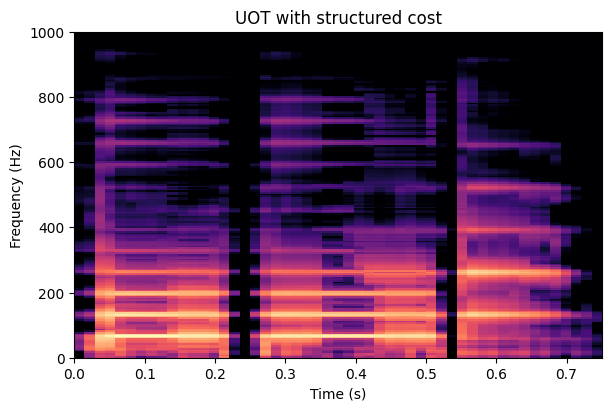

In [241]:
# take x.T.flatten() to vectorize (flatten) in a column-wise fashion (transpose)

x_UOT, loss_UOT, diff_UOT = uot_barycenter(x1.T.flatten(), 
                                           x2.T.flatten(), 
                                           c1, 
                                           c2, 
                                           rows1,
                                           cols1,
                                           rows2,
                                           cols2,
                                           eta=5,
                                           bary_size=X1.f_bins.size * X2.t_frames.size,
                                           nItermax=1000,
                                           verbose=False,
                                           return_loss=True,
                                           return_diff=True,
                                           thr=5e-7)

x_UOT = x_UOT.reshape(X2.t, X1.f).T # reshape vector to spectrogram shape

display_spectrogram(x_UOT, f_bins=X1.f_bins, t_frames=X2.t_frames, log=True, title='UOT with structured cost')

### Display 4 spectrograms

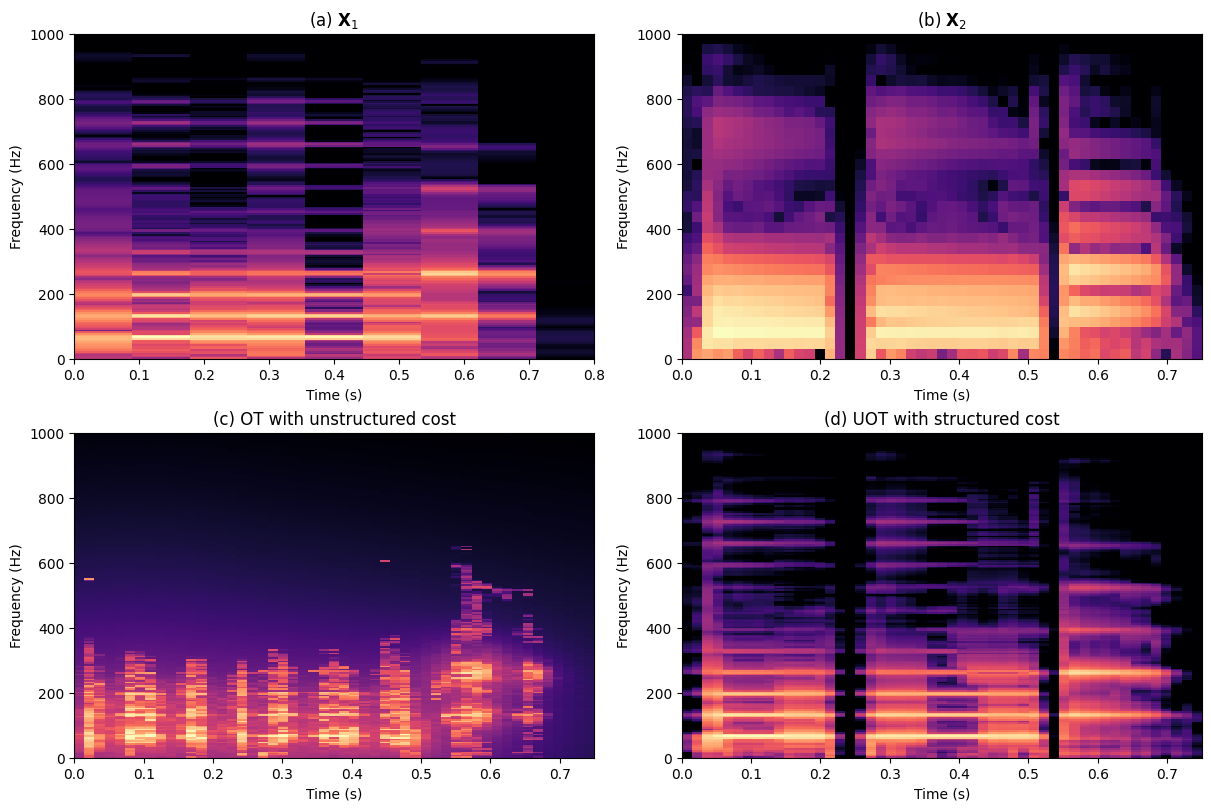

In [242]:
axes = new_axes(2, 2)

display_spectrogram(x1   , ax=axes[0, 0], f_bins=X1.f_bins, t_frames=X1.t_frames, log=True, logmin=-80, title=r"(a) $\mathbf{X}_1$")
display_spectrogram(x2   , ax=axes[0, 1], f_bins=X2.f_bins, t_frames=X2.t_frames, log=True, logmin=-80, title=r"(b) $\mathbf{X}_2$")
display_spectrogram(x_OT , ax=axes[1, 0], f_bins=X1.f_bins, t_frames=X2.t_frames, log=True, title='(c) OT with unstructured cost')
display_spectrogram(x_UOT, ax=axes[1, 1], f_bins=X1.f_bins, t_frames=X2.t_frames, log=True, title='(d) UOT with structured cost')


## Fig. 4 - Temporal windowing

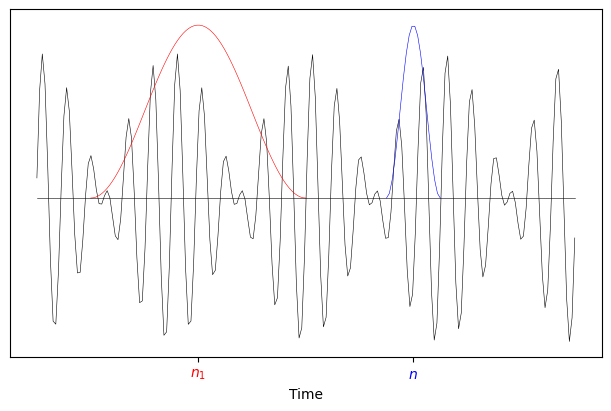

In [243]:
sr = 1000
t, signal = generate_toy_signal(sr=sr)

X1 = Spectrogram(signal, sr=sr, window_size_s=80e-3)
X2 = Spectrogram(signal, sr=sr, window_size_s=20e-3)

window_1 = X1.window.copy()
window_2 = X2.window.copy()

n_1 = 4  # index n_1
n   = 24 # index n

W1, W2 = X1.window_size, X2.window_size
H1, H2 = X1.hop_size, X2.hop_size

# truncate signal between 0.1 and 0.3 seconds for display
t_s, t_e = 0.10, 0.30
s_s, s_e = int(t_s * sr), int(t_e * sr)
t = np.linspace(t_s, t_e, s_e - s_s)
signal = signal[s_s:s_e]

# define windows' supports (see eq. 50)
t_s1, t_e1 = (n_1 * H1 - W1 / 2) / sr, (n_1 * H1 + W1 / 2) / sr
t_s2, t_e2 = (n * H2 - W2 / 2) / sr, (n * H2 + W2 / 2) / sr
T1 = np.linspace(t_s1, t_e1 , W1) # support of window 1
T2 = np.linspace(t_s2, t_e2 , W2) # support of window 2

# for better visualization
window_1 *= 1.2 * signal.max()
window_2 *= 1.2 * signal.max()

# timestamp of indexes n1 and n2
h_t1, h_t2 = (n_1 * H1) / sr, (n * H2) / sr

ax = new_axes()
plot_signal(signal, ax=ax, times=t)
ax.plot(T1, window_1, c='red', linewidth=.4, label=r'$W_1$')
ax.plot(T2, window_2, c='blue', linewidth=.4, label=r'$W_2$')
ax.plot(t, np.zeros_like(t), c='black', linewidth=.4) # plot line at origin

# add ticks for n and n'
ax.set_xticks([h_t1, h_t2])
ax.set_xticklabels([r"$n_1$", r"$n$"])
labs = ax.get_xticklabels()
labs[0].set_color('red')
labs[1].set_color('blue')

# other
ax.set_yticks([])
ax.set_xlabel('Time');


## Figs. 5 and 6 - Synthetic signals
## Tables I and II

Fig. 5 single tf packet

In [4]:
# Common STFT parameters
W1, W2         = 100e-3, 20e-3
hop_size, nfft = 10e-3, 100
dur            = .5
sr             = 1000

## Compute supports and cost matrices for UOT (same-grid and different-grid settings)

# Compute spectrogram of random signal to retrieve time and frequency samplings
signal = np.random.randn(int(dur * sr))

# same-grid setting
X1 = Spectrogram(signal, sr, W1, hop_size_s=hop_size, nfft=nfft)
X2 = Spectrogram(signal, sr, W2, hop_size_s=hop_size, nfft=nfft)
f_bins, t_frames = X1.f_bins, X2.t_frames

S  = time_freq_support(f_bins, t_frames, norm=True)
c1_s, rows1_s, cols1_s = cost_matrix_horizontal_overlap(S, S, W1, W2, X1.hop_size_s, X2.hop_size_s)
c2_s, rows2_s, cols2_s = cost_matrix_vertical_overlap(S, S, W1, W2)

# different-grid setting
X1 = Spectrogram(signal, sr, W1, hop_size_s=W1 / 2, nfft=nfft) # 75% overlap
X2 = Spectrogram(signal, sr, W2, hop_size_s=hop_size, nfft=None) # complete frequency sampling

S1 = time_freq_support(X1.f_bins, X1.t_frames, norm=True)
S2 = time_freq_support(X2.f_bins, X2.t_frames, norm=True)
c1_d, rows1_d, cols1_d = cost_matrix_horizontal_overlap(S1, S, W1, W2, X1.hop_size_s, X2.hop_size_s)
c2_d, rows2_d, cols2_d = cost_matrix_vertical_overlap(S2, S, W1, W2)

## Run experiment
np.random.seed(0)

# implementation parameters
N_sig = 100
eta = 10
tol = 5e-7
f_min, f_max = 100, 400
min_dur, max_dur = 0.025, 0.1
min_onset, max_offset = 0.05, dur - 0.05 # sensure that tf packets don't touch temporal support limits

N_eval = 50 # number of variations of delta_f, for plotting

# define error metrics for 5 spectrograms
f_error = np.zeros((5, N_sig, N_eval)) 
t_error = np.zeros((5, N_sig, N_eval))
# delta_t = 0 # evaluate only strict temporal regime

# runtime for same-grid and different-grid barycenter computation
runtime    = np.zeros((2, N_sig))
iterations = np.zeros((2, N_sig))

for i in range(5):
    signal, f, t_on, t_off = single_tf_packet(sr, 
                                              dur, 
                                              f_min=f_min, 
                                              f_max=f_max, 
                                              min_dur=min_dur, 
                                              max_dur=max_dur, 
                                              min_onset=min_onset, 
                                              max_offset=max_offset)

    ## same-grid

    X1_s = Spectrogram(signal, sr, W1, hop_size_s=hop_size, nfft=nfft)
    X2_s = Spectrogram(signal, sr, W2, hop_size_s=hop_size, nfft=nfft)
    x1_s, x2_s = X1_s.spectrogram(), X2_s.spectrogram()
    x1_s = x1_s[:, :X2_s.t] # crop last frames to ensure same size

    # uot barycenter
    start = time()
    x_s, iter_s = uot_barycenter(x1_s.T.flatten(), 
                                 x2_s.T.flatten(), 
                                 c1_s, 
                                 c2_s, 
                                 rows1_s,
                                 cols1_s,
                                 rows2_s,
                                 cols2_s,
                                 eta=eta,
                                 bary_size=f_bins.size * t_frames.size,
                                 nItermax=2000,
                                 verbose=False,
                                 return_iter=True,
                                 thr=tol)
    runtime[0, i] = time() - start
    iterations[0, i] = iter_s
    x_s = x_s.reshape(t_frames.size, f_bins.size).T # reshape vector to spectrogram shape
    
    # geometric mean
    x_g = (x1_s * x2_s)**.5

    ## different-grid

    X1_d = Spectrogram(signal, sr, W1, hop_size_s=W1/2, nfft=nfft)
    X2_d = Spectrogram(signal, sr, W2, hop_size_s=hop_size)
    x1_d, x2_d = X1_d.spectrogram(), X2_d.spectrogram()
    
    # uot barycenter
    start = time()
    x_d, iter_d = uot_barycenter(x1_d.T.flatten(), 
                                 x2_d.T.flatten(), 
                                 c1_d, 
                                 c2_d, 
                                 rows1_d,
                                 cols1_d,
                                 rows2_d,
                                 cols2_d,
                                 eta=eta,
                                 bary_size=f_bins.size * t_frames.size,
                                 nItermax=2000,
                                 verbose=False,
                                 return_iter=True,
                                 thr=tol)
    runtime[1, i] = time() - start
    iterations[1, i] = iter_d

    x_d = x_d.reshape(t_frames.size, f_bins.size).T # reshape vector to spectrogram shape

    ## report metrics

    for j in range(N_eval):
        delta_f, delta_t = X1_s.f_bins[j], X2_s.t_frames[j]
        f_error[0, i, j] = error_frequency(x1_s, f, delta_f, f_bins)
        f_error[1, i, j] = error_frequency(x2_s, f, delta_f, f_bins)
        f_error[2, i, j] = error_frequency(x_g , f, delta_f, f_bins)
        f_error[3, i, j] = error_frequency(x_s , f, delta_f, f_bins)
        f_error[4, i, j] = error_frequency(x_d , f, delta_f, f_bins)
        t_error[0, i, j] = error_time(x1_s, t_on, t_off, delta_t, t_frames)
        t_error[1, i, j] = error_time(x2_s, t_on, t_off, delta_t, t_frames)
        t_error[2, i, j] = error_time(x_g , t_on, t_off, delta_t, t_frames)
        t_error[3, i, j] = error_time(x_s , t_on, t_off, delta_t, t_frames)
        t_error[4, i, j] = error_time(x_d , t_on, t_off, delta_t, t_frames)

# save error metrics
np.save("data/SINGLE_TF_error_time_x1", t_error[0])
np.save("data/SINGLE_TF_error_time_x2", t_error[1])
np.save("data/SINGLE_TF_error_time_xg", t_error[2])
np.save("data/SINGLE_TF_error_time_xs", t_error[3])
np.save("data/SINGLE_TF_error_time_xd", t_error[4])
np.save("data/SINGLE_TF_error_freq_x1", f_error[0])
np.save("data/SINGLE_TF_error_freq_x2", f_error[1])
np.save("data/SINGLE_TF_error_freq_xg", f_error[2])
np.save("data/SINGLE_TF_error_freq_xs", f_error[3])
np.save("data/SINGLE_TF_error_freq_xd", f_error[4])
np.save("data/SINGLE_TF_runtime_s", runtime[0])
np.save("data/SINGLE_TF_runtime_d", runtime[0])
np.save("data/SINGLE_TF_iterations_s", iterations[0])
np.save("data/SINGLE_TF_iterations_d", iterations[0])

Display tables

In [12]:
print("Error in time:\n")

print(f"{'Spectrogram':<22} {'E_t x 10^{-3}':>18}")
print(f"{'X1':<22} {f'{t_error[0, 0].mean() * 1000:.3f} ± {t_error[0].std() / np.sqrt(N_sig) * 1000:.3f}':>18}")
print(f"{'X2':<22} {f'{t_error[1, 0].mean() * 1000:.3f} ± {t_error[1].std() / np.sqrt(N_sig) * 1000:.3f}':>18}")
print(f"{'Geom':<22} {f'{t_error[2, 0].mean() * 1000:.3f} ± {t_error[2].std() / np.sqrt(N_sig) * 1000:.3f}':>18}")
print(f"{'UOT (same grid)':<22} {f'{t_error[3, 0].mean() * 1000:.3f} ± {t_error[3].std() / np.sqrt(N_sig) * 1000:.3f}':>18}")
print(f"{'UOT (different grid)':<22} {f'{t_error[4, 0].mean() * 1000:.3f} ± {t_error[4].std() / np.sqrt(N_sig) * 1000:.3f}':>18}")

print("\nRuntime:\n")

print(f"{'UOT barycenter':<22} {'Runtime (s)':>16} {'Iterations':>16}")
print(f"{'UOT (same grid)':<22} {f'{runtime[0].mean():.3f} ± {runtime[0].std() / np.sqrt(N_sig):.3f}':>18} {f'{iterations[0].mean():.3f} ± {iterations[0].std() / np.sqrt(N_sig):.3f}':>18}")
print(f"{'UOT (different grid)':<22} {f'{runtime[1].mean():.3f} ± {runtime[1].std() / np.sqrt(N_sig):.3f}':>18} {f'{iterations[1].mean():.3f} ± {iterations[1].std() / np.sqrt(N_sig):.3f}':>18}")

Error in time:

Spectrogram                 E_t x 10^{-3}
X1                          1.092 ± 0.245
X2                          0.000 ± 0.000
Geom                        0.000 ± 0.001
UOT (same grid)             0.000 ± 0.000
UOT (different grid)        0.000 ± 0.000

Runtime:

UOT barycenter              Runtime (s)       Iterations
UOT (same grid)             0.095 ± 0.041    53.770 ± 23.442
UOT (different grid)        0.010 ± 0.004    23.950 ± 10.559


Display Fig. 5

Text(0.5, 0, '$\\Delta_f$ (Hz)')

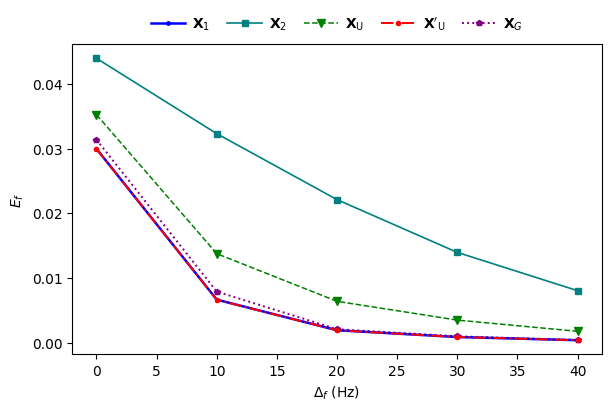

In [34]:
max_delta_f = 40
max_idx = idx_at_value(max_delta_f, f_bins)
x_axis = f_bins[:max_idx + 1]
axes = new_axes()

axes.plot(x_axis, f_error[0].mean(axis=0)[:max_idx + 1],  ls='-',  marker='.', c='blue',   lw=1.8, ms=5, zorder=5, label=r'$\mathbf{X}_1$',)
axes.plot(x_axis, f_error[1].mean(axis=0)[:max_idx + 1],  ls='-',  marker='s', c='teal',   lw=1.2, ms=4, zorder=3, label=r'$\mathbf{X}_2$',)
axes.plot(x_axis, f_error[2].mean(axis=0)[:max_idx + 1],  ls='--', marker='v', c='green',  lw=1.1, ms=6, zorder=4, label=r'$\mathbf{X}_\mathrm{U}$',  )
axes.plot(x_axis, f_error[3].mean(axis=0)[:max_idx + 1],  ls='-.', marker='o', c='red',    lw=1.4, ms=3, zorder=6, label=r"$\mathbf{X}'_\mathrm{U}$", )
axes.plot(x_axis, f_error[4].mean(axis=0)[:max_idx + 1],  ls=':',  marker='p', c='purple', lw=1.4, ms=4, zorder=2, label=r'$\mathbf{X}_G$',)


axes.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=5,
    frameon=False,
    handlelength=2.5,
    columnspacing=1.2,
    handletextpad=0.5,
    borderaxespad=0.0
)

axes.set_ylabel(r'$E_f$')
axes.set_xlabel(r'$\Delta_f$ (Hz)')

Fig. 6 mixture of tf packets

In [1]:
# Import libraries

from src.spectrogram import *
from src.barycenter import *
from src.cost_matrix import *
from src.display import *
from src.spectrogram import *
from src.synthetic_signals import *
from src.utils import *

import matplotlib.pyplot as plt
import librosa
from scipy.signal.windows import hann

from time import time

In [4]:
# Common STFT parameters
W1, W2         = 100e-3, 20e-3
hop_size, nfft = 5e-3, 100
dur            = .5
sr             = 1000

## Compute supports and cost matrices for UOT (same-grid and different-grid settings)

# Compute spectrogram of random signal to retrieve time and frequency samplings
signal = np.random.randn(int(dur * sr))

# same-grid setting
X1 = Spectrogram(signal, sr, W1, hop_size_s=hop_size, nfft=nfft)
X2 = Spectrogram(signal, sr, W2, hop_size_s=hop_size, nfft=nfft)
f_bins, t_frames = X1.f_bins, X2.t_frames

S  = time_freq_support(f_bins, t_frames, norm=True)
c1_s, rows1_s, cols1_s = cost_matrix_horizontal_overlap(S, S, W1, W2, X1.hop_size_s, X2.hop_size_s)
c2_s, rows2_s, cols2_s = cost_matrix_vertical_overlap(S, S, W1, W2)

# different-grid setting
X1 = Spectrogram(signal, sr, W1, hop_size_s=W1 / 2, nfft=nfft) # 75% overlap
X2 = Spectrogram(signal, sr, W2, hop_size_s=hop_size, nfft=None) # complete frequency sampling

S1 = time_freq_support(X1.f_bins, X1.t_frames, norm=True)
S2 = time_freq_support(X2.f_bins, X2.t_frames, norm=True)
c1_d, rows1_d, cols1_d = cost_matrix_horizontal_overlap(S1, S, W1, W2, X1.hop_size_s, X2.hop_size_s)
c2_d, rows2_d, cols2_d = cost_matrix_vertical_overlap(S2, S, W1, W2)

## Run experiment
np.random.seed(0)

# implementation parameters
N_sig = 100
eta = 10
tol = 5e-7
f_min, f_max = 100, 400
min_dur, max_dur = 0.025, 0.1
min_onset, max_offset = 0.05, dur - 0.05 # sensure that tf packets don't touch temporal support limits

N_eval = 50 # number of variations of delta_f, for plotting

# define error metrics for 5 spectrograms
overall_error = np.zeros((5, N_sig, N_eval, N_eval)) # N_specs x N_sig x N_delta_t x N_delta_f

# runtime for same-grid and different-grid barycenter computation
runtime    = np.zeros((2, N_sig))
iterations = np.zeros((2, N_sig))

for i in range(1):
    n_packets = np.random.randint(2, 11)
    signal, freqs, t_ons, t_offs = multi_tf_packet(sr, 
                                                   dur, 
                                                   n_packets,
                                                   f_min=f_min, 
                                                   f_max=f_max, 
                                                   min_dur=min_dur, 
                                                   max_dur=max_dur, 
                                                   min_onset=min_onset, 
                                                   max_offset=max_offset)

    ## same-grid

    X1_s = Spectrogram(signal, sr, W1, hop_size_s=hop_size, nfft=nfft)
    X2_s = Spectrogram(signal, sr, W2, hop_size_s=hop_size, nfft=nfft)
    x1_s, x2_s = X1_s.spectrogram(), X2_s.spectrogram()
    x1_s = x1_s[:, :X2_s.t] # crop last frames to ensure same size

    # uot barycenter
    start = time()
    x_s, iter_s = uot_barycenter(x1_s.T.flatten(), 
                                 x2_s.T.flatten(), 
                                 c1_s, 
                                 c2_s, 
                                 rows1_s,
                                 cols1_s,
                                 rows2_s,
                                 cols2_s,
                                 eta=eta,
                                 bary_size=f_bins.size * t_frames.size,
                                 nItermax=2000,
                                 verbose=False,
                                 return_iter=True,
                                 thr=tol)
    runtime[0, i] = time() - start
    iterations[0, i] = iter_s
    x_s = x_s.reshape(t_frames.size, f_bins.size).T # reshape vector to spectrogram shape
    
    # geometric mean
    x_g = (x1_s * x2_s)**.5

    ## different-grid

    X1_d = Spectrogram(signal, sr, W1, hop_size_s=W1/2, nfft=nfft)
    X2_d = Spectrogram(signal, sr, W2, hop_size_s=hop_size)
    x1_d, x2_d = X1_d.spectrogram(), X2_d.spectrogram()
    
    # uot barycenter
    start = time()
    x_d, iter_d = uot_barycenter(x1_d.T.flatten(), 
                                 x2_d.T.flatten(), 
                                 c1_d, 
                                 c2_d, 
                                 rows1_d,
                                 cols1_d,
                                 rows2_d,
                                 cols2_d,
                                 eta=eta,
                                 bary_size=f_bins.size * t_frames.size,
                                 nItermax=2000,
                                 verbose=False,
                                 return_iter=True,
                                 thr=tol)
    runtime[1, i] = time() - start
    iterations[1, i] = iter_d

    x_d = x_d.reshape(t_frames.size, f_bins.size).T # reshape vector to spectrogram shape

    ## report metrics

    for j in range(N_eval):
        delta_t = X2_s.t_frames[j]
        for k in range(N_eval):
            delta_f = X1_s.f_bins[k]
            overall_error[0, i, j, k] = error_overall(x1_s, freqs, t_ons, t_offs, delta_f, delta_t, f_bins, t_frames) 
            overall_error[1, i, j, k] = error_overall(x2_s, freqs, t_ons, t_offs, delta_f, delta_t, f_bins, t_frames) 
            overall_error[2, i, j, k] = error_overall(x_g , freqs, t_ons, t_offs, delta_f, delta_t, f_bins, t_frames) 
            overall_error[3, i, j, k] = error_overall(x_s , freqs, t_ons, t_offs, delta_f, delta_t, f_bins, t_frames) 
            overall_error[4, i, j, k] = error_overall(x_d , freqs, t_ons, t_offs, delta_f, delta_t, f_bins, t_frames) 

# save error metrics
np.save("data/MULTI_TF_error_overall_x1", overall_error[0])
np.save("data/MULTI_TF_error_overall_x2", overall_error[1])
np.save("data/MULTI_TF_error_overall_xg", overall_error[2])
np.save("data/MULTI_TF_error_overall_xs", overall_error[3])
np.save("data/MULTI_TF_error_overall_xd", overall_error[4])
np.save("data/MULTI_TF_runtime_s", runtime[0])
np.save("data/MULTI_TF_runtime_d", runtime[0])
np.save("data/MULTI_TF_iterations_s", iterations[0])
np.save("data/MULTI_TF_iterations_d", iterations[0])

Text(0.5, 0, '$\\Delta_f$ (Hz)')

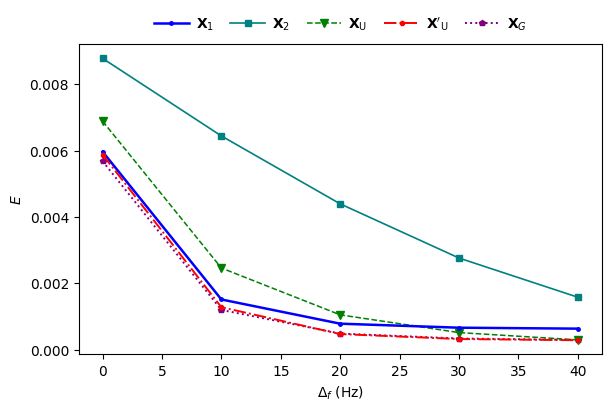

In [11]:
max_delta_f = 40
max_idx = idx_at_value(max_delta_f, f_bins)
x_axis = f_bins[:max_idx + 1]
axes = new_axes()

axes.plot(x_axis, overall_error[0, :, 0].mean(axis=0)[:max_idx + 1],  ls='-',  marker='.', c='blue',   lw=1.8, ms=5, zorder=5, label=r'$\mathbf{X}_1$',)
axes.plot(x_axis, overall_error[1, :, 0].mean(axis=0)[:max_idx + 1],  ls='-',  marker='s', c='teal',   lw=1.2, ms=4, zorder=3, label=r'$\mathbf{X}_2$',)
axes.plot(x_axis, overall_error[2, :, 0].mean(axis=0)[:max_idx + 1],  ls='--', marker='v', c='green',  lw=1.1, ms=6, zorder=4, label=r'$\mathbf{X}_\mathrm{U}$',  )
axes.plot(x_axis, overall_error[3, :, 0].mean(axis=0)[:max_idx + 1],  ls='-.', marker='o', c='red',    lw=1.4, ms=3, zorder=6, label=r"$\mathbf{X}'_\mathrm{U}$", )
axes.plot(x_axis, overall_error[4, :, 0].mean(axis=0)[:max_idx + 1],  ls=':',  marker='p', c='purple', lw=1.4, ms=4, zorder=2, label=r'$\mathbf{X}_G$',)


axes.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=5,
    frameon=False,
    handlelength=2.5,
    columnspacing=1.2,
    handletextpad=0.5,
    borderaxespad=0.0
)

axes.set_ylabel(r'$E$')
axes.set_xlabel(r'$\Delta_f$ (Hz)')

In [12]:
print("\nRuntime:\n")

print(f"{'UOT barycenter':<22} {'Runtime (s)':>16} {'Iterations':>16}")
print(f"{'UOT (same grid)':<22} {f'{runtime[0].mean():.3f} ± {runtime[0].std() / np.sqrt(N_sig):.3f}':>18} {f'{iterations[0].mean():.3f} ± {iterations[0].std() / np.sqrt(N_sig):.3f}':>18}")
print(f"{'UOT (different grid)':<22} {f'{runtime[1].mean():.3f} ± {runtime[1].std() / np.sqrt(N_sig):.3f}':>18} {f'{iterations[1].mean():.3f} ± {iterations[1].std() / np.sqrt(N_sig):.3f}':>18}")


Runtime:

UOT barycenter              Runtime (s)       Iterations
UOT (same grid)             0.050 ± 0.050    11.220 ± 11.164
UOT (different grid)        0.006 ± 0.006      6.490 ± 6.457


## Figs. 10 and 11 - Target mel-frequency axis support

Fig. 10 - Mel support

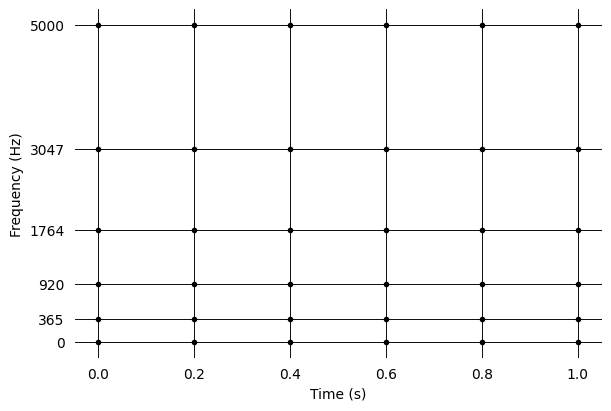

In [18]:
sr = 10000

m_bins = mel_frequency_bins(6, sr)
t_frames   = np.linspace(0, 1, 6)

S_mel = time_freq_support(m_bins, t_frames, norm=False)

display_support(S_mel)

We first compute a barycenter directly on the mel scale between $\mathbf{X}_1$ and $\mathbf{X}_2$. We compare it with:

* Mel spectrogram of $\mathbf{X}_1$ computed using traditional pipeline.
* Mel spectrogram of $\mathbf{X}_2$ computed using traditional pipeline.
* 2-step super resolution mel: (i) compute super-resolution between $\mathbf{X}_1$ and $\mathbf{X}_2$ (ii) compute mel using traditional pipeline


Convergence attained after 268 iterations.
Convergence attained after 147 iterations.


/Users/davidv/david/code/papers/fusion-ot/.venv/lib/python3.14/site-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


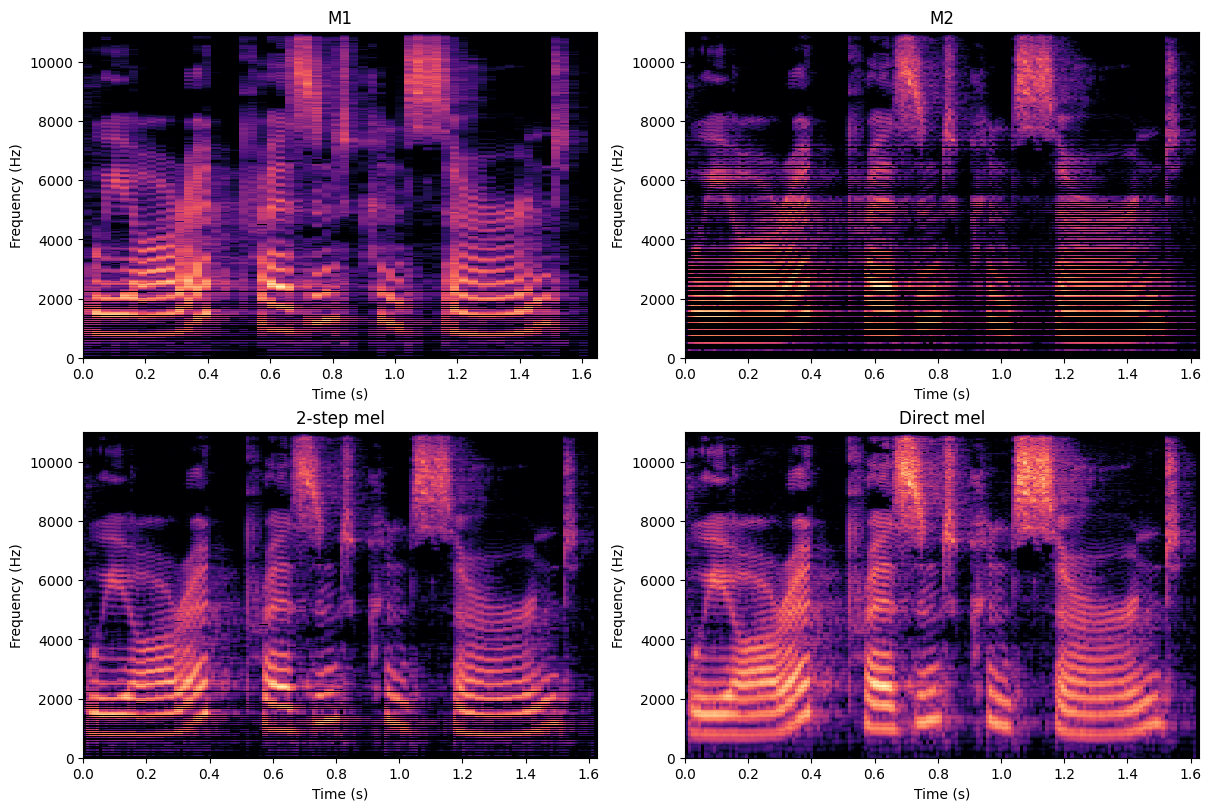

In [19]:
sr = 22050
signal, _ = librosa.load('example_sounds/woman_speech.wav', sr=sr)

X1 = Spectrogram(signal, sr, 60e-3)
X2 = Spectrogram(signal, sr, 20e-3)

x1 = X1.spectrogram()
x2 = X2.spectrogram()

n_bins = 500
m_bins_1 = mel_frequency_bins(n_bins, sr)

S1 = time_freq_support(X1.f_bins, X1.t_frames)
S2 = time_freq_support(X2.f_bins, X2.t_frames)

# direct mel

S_mel  = time_freq_support(m_bins_1, X2.t_frames)
c1, rows1, cols1 = cost_matrix_horizontal_overlap_mel(S1, S_mel, X1.window_size, X2.window_size, sr, X1.hop_size, X2.hop_size)
c2, rows2, cols2 = cost_matrix_vertical_overlap_mel(S2, S_mel, X1.window_size, X2.window_size, sr)

c1 /= c1.max()
c2 /= c2.max()

thr = 1e-5

x_mel = uot_barycenter(x1.T.flatten(), 
                       x2.T.flatten(), 
                       c1, 
                       c2, 
                       rows1,
                       cols1,
                       rows2,
                       cols2,
                       eta=.5,
                       bary_size= m_bins_1.size * X2.t,
                       nItermax=500,
                       verbose=True,
                       return_loss=False,
                       return_diff=False,
                       thr=1e-5)

x_mel = x_mel.reshape(X2.t, m_bins_1.size).T

# 2-step mel

S = time_freq_support(X1.f_bins, X2.t_frames)

c1, rows1, cols1 = cost_matrix_horizontal_overlap(S1, S, X1.window_size, X2.window_size, X1.hop_size, X2.hop_size)
c2, rows2, cols2 = cost_matrix_vertical_overlap(S2, S, X1.window_size, X2.window_size)

x_uot = uot_barycenter(x1.T.flatten(), 
                       x2.T.flatten(), 
                       c1, 
                       c2, 
                       rows1,
                       cols1,
                       rows2,
                       cols2,
                       eta=1,
                       bary_size=x1.shape[0] * x2.shape[1],
                       nItermax=500,
                       verbose=True,
                       return_loss=False,
                       return_diff=False,
                       thr=1e-5)


x_uot = x_uot.reshape(X2.t, X1.f).T
x_uot_mel = librosa.feature.melspectrogram(S=x_uot, n_mels=n_bins, htk=True)

# Mel spectrograms of X1 and X2

m1 = librosa.feature.melspectrogram(S=x1, n_mels=n_bins, htk=True)
m2 = librosa.feature.melspectrogram(S=x2, n_mels=n_bins, htk=True)

axes = new_axes(2, 2)
display_spectrogram(m1, ax=axes[0, 0], title='M1', f_bins=m_bins_1, t_frames=X1.t_frames, log=True)
display_spectrogram(m2, ax=axes[0, 1], title='M2', f_bins=m_bins_1, t_frames=X2.t_frames, log=True)
display_spectrogram(x_uot_mel, ax=axes[1, 0], title='2-step mel', f_bins=m_bins_1, t_frames=X2.t_frames, log=True)
display_spectrogram(x_mel, ax=axes[1, 1], title='Direct mel', f_bins=m_bins_1, t_frames=X2.t_frames, log=True)

Fig. 11 - Compare super-resolution mel with another mel

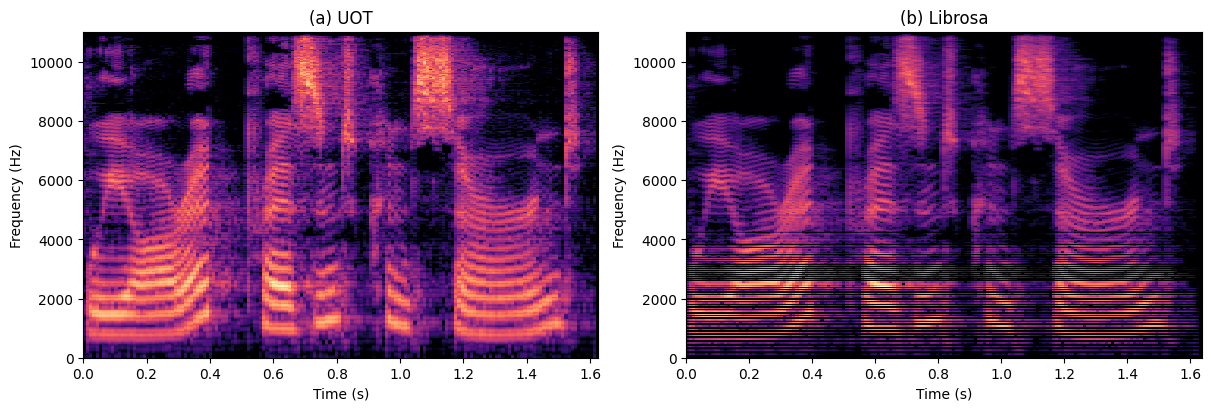

In [20]:
# Other spectrogram to compare with

X3 = Spectrogram(signal, sr, window_size_s=40e-3, hop_size_s=X2.hop_size_s)
m3 = librosa.feature.melspectrogram(S=X3.spectrogram(), n_mels=x_mel.shape[0], htk=True)

axes = new_axes(1, 2)
display_spectrogram(x_mel, ax=axes[0], title='(a) UOT', f_bins=m_bins_1, t_frames=X2.t_frames, log=True)
display_spectrogram(m3, ax=axes[1], title='(b) Librosa', f_bins=m_bins_1, t_frames=X3.t_frames, log=True)

## Fig 12 - Fourier transform of Hann window

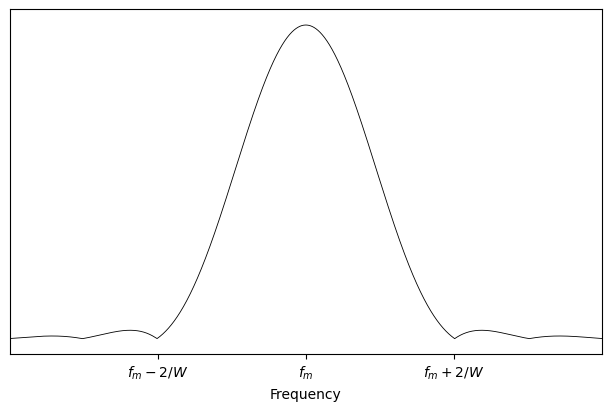

In [21]:
sr = 8000
window_size_seconds = 20e-3

window = hann(int(sr * window_size_seconds))
window_ft = np.fft.fft(window, n=100000)
window_ft = np.abs(window_ft)
freqs = np.fft.fftfreq(window_ft.size, d=1/sr)

window_ft = np.fft.fftshift(window_ft) # center at f=0Hz.
freqs = np.fft.fftshift(freqs)

axes = new_axes()
axes.set_yticks([])
axes.plot(freqs, window_ft, c='black', linewidth=.6)
axes.set_xlabel("Frequency")
axes.set_xticks([-2 / window_size_seconds, 0,  2 / window_size_seconds])
axes.set_xticklabels([r"$f_m -2 / W$", r"$f_m$", r"$f_m +2 / W$"]);
axes.set_xlim(-200, 200);